<a href="https://colab.research.google.com/github/shirin6767saleh/code-/blob/Fnew/column%20put%20to%20the%20test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
teta=0 , N=4m```



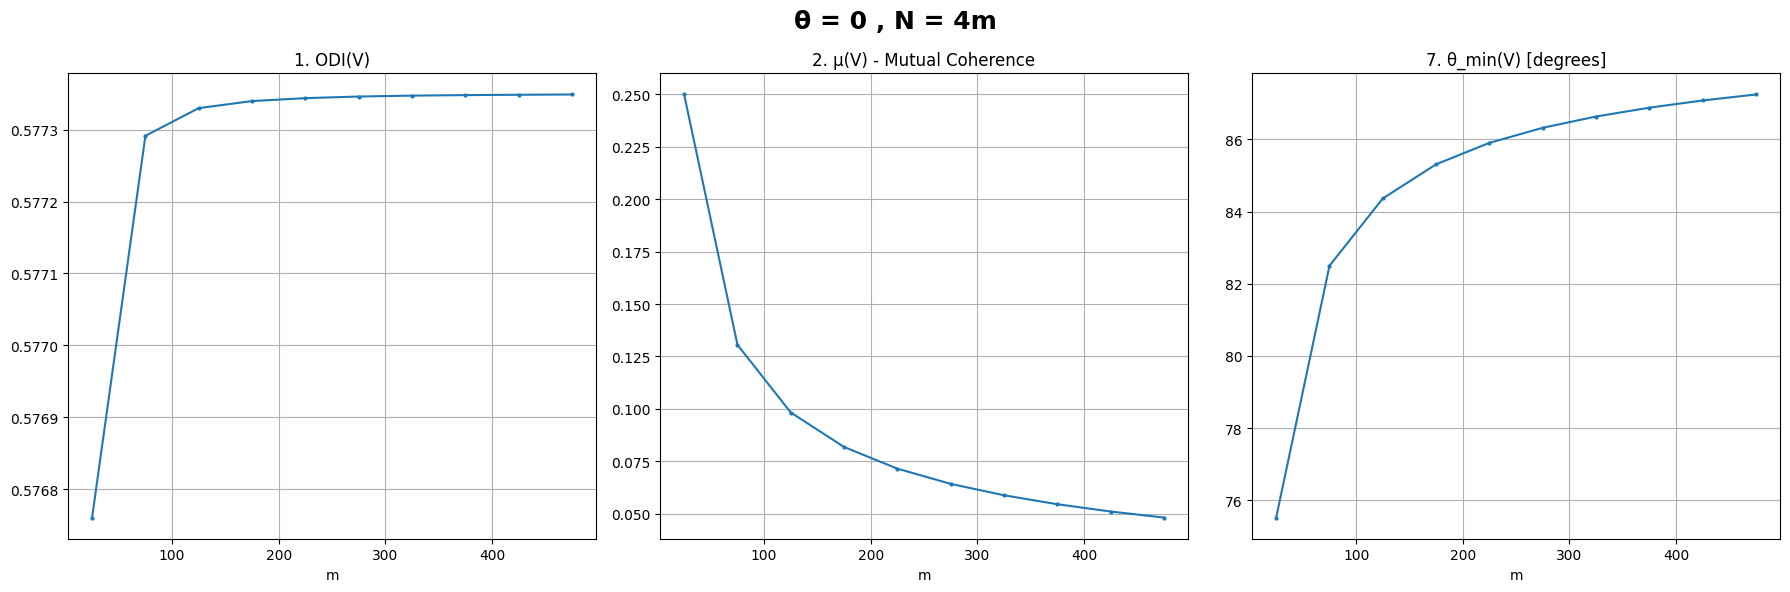

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

m_values = np.arange(25, 501, 50)
mu_vals = []

ODI_vals = []
mu_vals = []
cond_vals = []
Q_norm_vals = []
tight_frame_vals = []
coherence_vals = []
theta_min_vals = []
objective_vals = []

def normalize_columns(V):
    return V / np.linalg.norm(V, axis=0)

def compute_Gram(V):
    return V.T @ V

def optimization_objective(V):
    G = compute_Gram(V)
    return np.linalg.norm(G - np.eye(G.shape[0]), 'fro')**2

for m in m_values:
    N = 4 * m
    t = 0
    w = np.exp((-2j * np.pi) / N)

    Gt = np.zeros((N, N), dtype=complex)
    for k in range(N):
        for l in range(N):
            Gt[k, l] = (1 / np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

    Ct = np.zeros((N, N))
    St = np.zeros((N, N))
    for k in range(N):
        for l in range(N):
            angle = (k - t/2) * (l - t/2) * (2 * np.pi / N)
            Ct[k, l] = (2 / np.sqrt(N)) * np.cos(angle)
            St[k, l] = (2 / np.sqrt(N)) * np.sin(angle)

    I = np.eye(N)
    J_N_1 = np.fliplr(np.eye(N - 1, dtype=int))
    direct_sum_matrix = block_diag(1, J_N_1)

    P1 = Ct + (I + direct_sum_matrix)
    Pm1 = (I + direct_sum_matrix) - Ct
    Pt = (I - direct_sum_matrix) - St
    Pt1 = (I - direct_sum_matrix) + St

    m_idx = m
    slice1 = P1[:, 0:m_idx]
    slice2 = P1[:, 2*m_idx].reshape(-1, 1)
    slice3 = Pm1[:, 0:m_idx]
    slice4 = Pt[:, 1:m_idx]
    slice5 = Pt1[:, 1:m_idx]
    slice6 = Pt1[:, 2*m_idx-1].reshape(-1, 1)

    # Function to normalize a single column
    def normalize_column(col):
        return col / np.linalg.norm(col)

    # Function to normalize each column of a matrix separately
    def normalize_columns(matrix):
        return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

    # Normalize each slice individually
    slice1_norm = normalize_columns(slice1)
    slice2_norm = normalize_columns(slice2)
    slice3_norm = normalize_columns(slice3)
    slice4_norm = normalize_columns(slice4)
    slice5_norm = normalize_columns(slice5)
    slice6_norm = normalize_columns(slice6)



    V = np.concatenate([slice1_norm, slice2_norm, slice3_norm, slice4_norm, slice5_norm, slice6_norm], axis=1)

    G = V.T @ V
    diag_G = np.diag(np.diag(G))
    norm_G = np.linalg.norm(G, 'fro')
    norm_diff = np.linalg.norm(G - diag_G, 'fro')
    ODI_vals.append(norm_diff / norm_G)

    mu_vals.append(np.max([abs(np.dot(V[:, i], V[:, j])) / (np.linalg.norm(V[:, i]) * np.linalg.norm(V[:, j]))
                           for i in range(V.shape[1]) for j in range(i + 1, V.shape[1])]))

    s = np.linalg.svd(V, compute_uv=False)
    cond_vals.append(np.max(s) / np.min(s))

    Q, _ = np.linalg.qr(V)
    Q_norm_vals.append(np.linalg.norm(Q.T @ Q - np.eye(Q.shape[1]), 'fro'))

    VVt = V @ V.T
    c = np.trace(VVt) / VVt.shape[0]
    tight_frame_vals.append(c)

    Vn = normalize_columns(V)
    max_inner = 0
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = abs(np.dot(Vn[:, i], Vn[:, j]))
            if inner > max_inner:
                max_inner = inner
    coherence_vals.append(max_inner)

    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    Vopt = Vn.copy()
    lr = 0.01
    for _ in range(50):
        Gopt = compute_Gram(Vopt)
        grad = 4 * Vopt @ (Gopt - np.eye(Gopt.shape[0]))
        Vopt -= lr * grad
        Vopt = normalize_columns(Vopt)
    objective_vals.append(optimization_objective(Vopt))

# Plotting all 8 metrics
# Plotting only metrics 1 (ODI), 2 (mu), and 7 (theta_min)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = [
    "1. ODI(V)",
    "2. μ(V) - Mutual Coherence",
    "3. κ(V) - Condition Number",
    "7. θ_min(V) [degrees]"
]
data_lists = [
    ODI_vals,
    mu_vals,
    cond_valsو
    theta_min_vals
]

for ax, title, data in zip(axes, titles, data_lists):
    ax.plot(m_values, data, marker='o', markersize=2)
    ax.set_title(title)
    ax.set_xlabel("m")
    ax.grid(True)

fig.suptitle("θ = 0 , N = 4m", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


teta=-1,N=4m

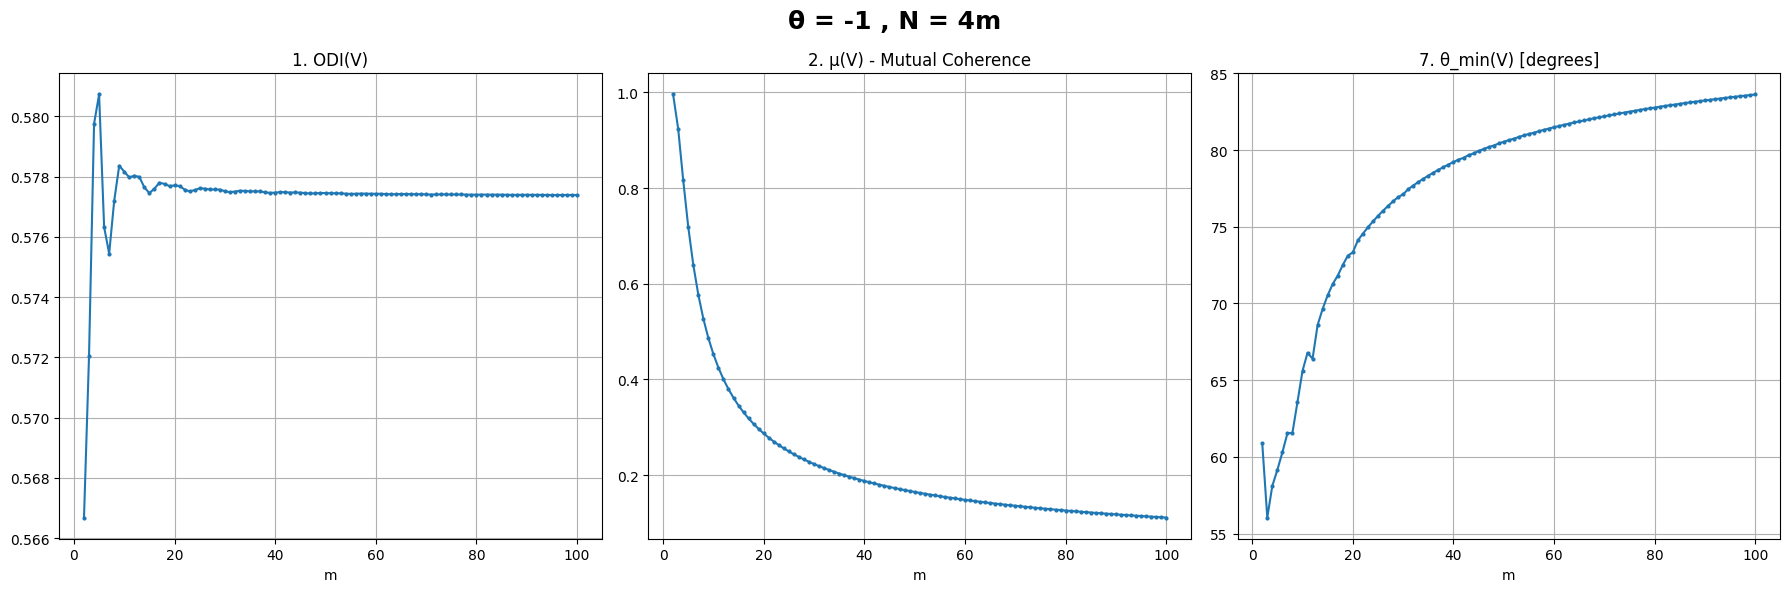

In [2]:
import numpy as np
import matplotlib.pyplot as plt

m_values = np.arange(25, 501, 50)
mu_vals = []

ODI_vals = []
mu_vals = []
cond_vals = []
Q_norm_vals = []
tight_frame_vals = []
coherence_vals = []
theta_min_vals = []
objective_vals = []

def normalize_columns(V):
    return V / np.linalg.norm(V, axis=0)

def compute_Gram(V):
    return V.T @ V

def optimization_objective(V):
    G = compute_Gram(V)
    return np.linalg.norm(G - np.eye(G.shape[0]), 'fro')**2

for m in m_values:
    N = 4 * m
    t = -1
    w = np.exp((-2j * np.pi) / N)

    Gt = np.zeros((N, N), dtype=complex)
    for k in range(N):
        for l in range(N):
            Gt[k, l] = (1 / np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

    Ct = np.zeros((N, N))
    St = np.zeros((N, N))
    for k in range(N):
        for l in range(N):
            angle = (k - t/2) * (l - t/2) * (2 * np.pi / N)
            Ct[k, l] = (2 / np.sqrt(N)) * np.cos(angle)
            St[k, l] = (2 / np.sqrt(N)) * np.sin(angle)

    I = np.eye(N)
    J = np.flipud(I)

    P1 = Ct + I - J
    Pm1 = Ct - I + J
    Pt = St - I - J
    Pt1 = St + I + J

    m_idx = m
    slice1 = P1[:, 0:m_idx]
    slice2 = Pm1[:, 0:m_idx]
    slice3 = Pt[:, 0:m_idx]
    slice4 = Pt1[:, 0:m_idx]


     # Function to normalize a single column
    def normalize_column(col):
        return col / np.linalg.norm(col)

    # Function to normalize each column of a matrix separately
    def normalize_columns(matrix):
        return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

    # Normalize each slice individually
    slice1_norm = normalize_columns(slice1)
    slice2_norm = normalize_columns(slice2)
    slice3_norm = normalize_columns(slice3)
    slice4_norm = normalize_columns(slice4)


    V = np.concatenate([slice1_norm, slice2_norm, slice3_norm, slice4_norm], axis=1)

    # Compute all metrics
    G = V.T @ V
    diag_G = np.diag(np.diag(G))
    norm_G = np.linalg.norm(G, 'fro')
    norm_diff = np.linalg.norm(G - diag_G, 'fro')
    ODI_vals.append(norm_diff / norm_G)

    mu_vals.append(np.max([abs(np.dot(V[:, i], V[:, j])) / (np.linalg.norm(V[:, i]) * np.linalg.norm(V[:, j]))
                           for i in range(V.shape[1]) for j in range(i + 1, V.shape[1])]))

    s = np.linalg.svd(V, compute_uv=False)
    cond_vals.append(np.max(s) / np.min(s))

    Q, _ = np.linalg.qr(V)
    Q_norm_vals.append(np.linalg.norm(Q.T @ Q - np.eye(Q.shape[1]), 'fro'))

    VVt = V @ V.T
    c = np.trace(VVt) / VVt.shape[0]
    tight_frame_vals.append(c)

    Vn = normalize_columns(V)
    max_inner = 0
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = abs(np.dot(Vn[:, i], Vn[:, j]))
            if inner > max_inner:
                max_inner = inner
    coherence_vals.append(max_inner)

    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    # Optimization
    Vopt = Vn.copy()
    lr = 0.01
    for _ in range(50):
        Gopt = compute_Gram(Vopt)
        grad = 4 * Vopt @ (Gopt - np.eye(Gopt.shape[0]))
        Vopt -= lr * grad
        Vopt = normalize_columns(Vopt)
    objective_vals.append(optimization_objective(Vopt))

# Plotting all 8 metrics
# Plotting only metrics 1 (ODI), 2 (mu), and 7 (theta_min)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = [
    "1. ODI(V)",
    "2. μ(V) - Mutual Coherence",
    "7. θ_min(V) [degrees]"
]
data_lists = [
    ODI_vals,
    mu_vals,
    theta_min_vals
]

for ax, title, data in zip(axes, titles, data_lists):
    ax.plot(m_values, data, marker='o', markersize=2)
    ax.set_title(title)
    ax.set_xlabel("m")
    ax.grid(True)

fig.suptitle("θ = -1 , N = 4m", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

teta=N-1 , N=4m

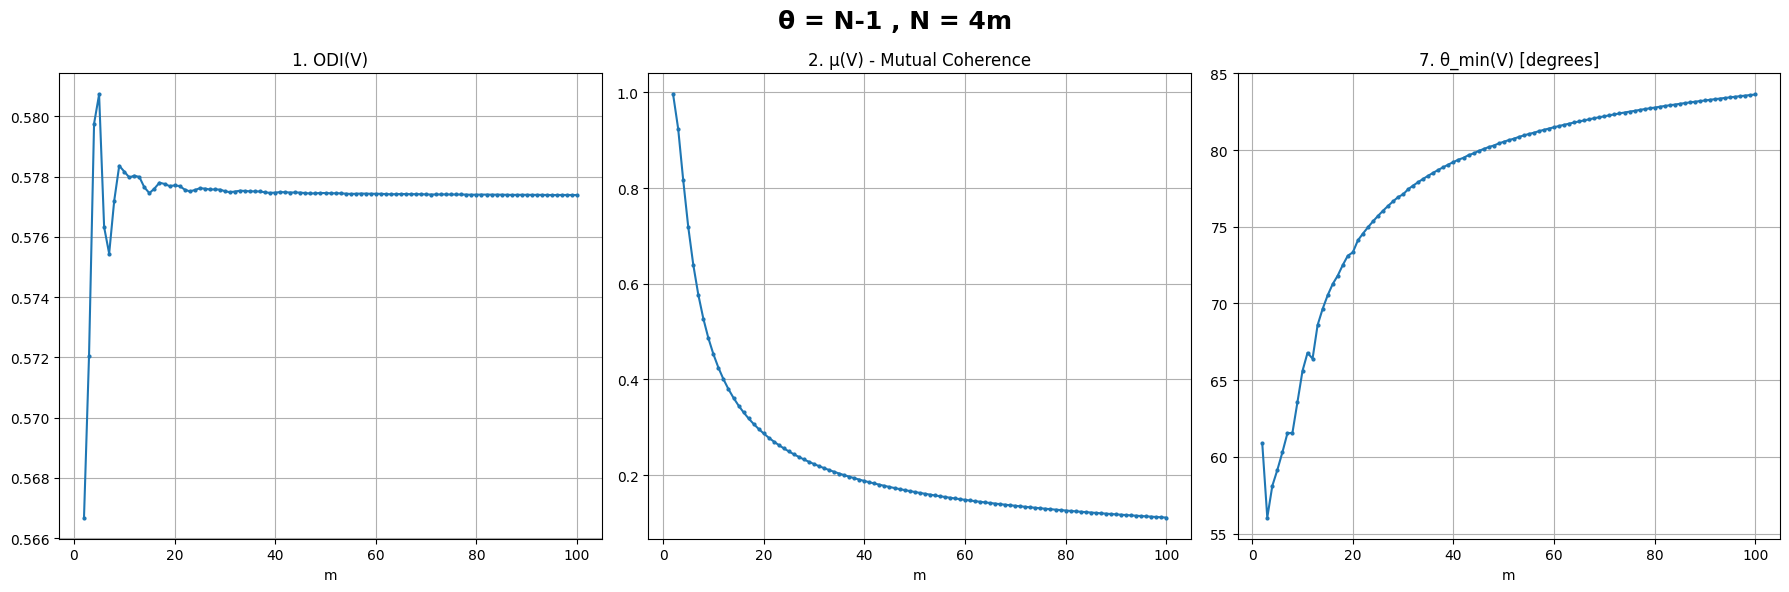

In [3]:
import numpy as np
import matplotlib.pyplot as plt

m_values = np.arange(25, 501, 50)
mu_vals = []

ODI_vals = []
mu_vals = []
cond_vals = []
Q_norm_vals = []
tight_frame_vals = []
coherence_vals = []
theta_min_vals = []
objective_vals = []

def normalize_columns(V):
    return V / np.linalg.norm(V, axis=0)

def compute_Gram(V):
    return V.T @ V

def optimization_objective(V):
    G = compute_Gram(V)
    return np.linalg.norm(G - np.eye(G.shape[0]), 'fro')**2

for m in m_values:
    N = 4 * m
    t = N - 1
    w = np.exp((-2j * np.pi) / N)

    Gt = np.zeros((N, N), dtype=complex)
    for k in range(N):
        for l in range(N):
            Gt[k, l] = (1 / np.sqrt(N)) * w ** ((k - t/2) * (l - t/2))

    Ct = np.zeros((N, N))
    St = np.zeros((N, N))
    for k in range(N):
        for l in range(N):
            angle = (k - t/2) * (l - t/2) * (2 * np.pi / N)
            Ct[k, l] = (2 / np.sqrt(N)) * np.cos(angle)
            St[k, l] = (2 / np.sqrt(N)) * np.sin(angle)

    I = np.eye(N)
    J = np.flipud(I)

    P1 = Ct + I + J
    Pm1 = Ct - I - J
    Pt = St - I + J
    Pt1 = St + I - J

    m_idx = m
    slice1 = P1[:, m_idx:2 * m_idx]
    slice2 = Pm1[:, m_idx:2 * m_idx]
    slice3 = Pt[:, m_idx:2 * m_idx]
    slice4 = Pt1[:, m_idx:2 * m_idx]

     # Function to normalize a single column
    def normalize_column(col):
        return col / np.linalg.norm(col)

    # Function to normalize each column of a matrix separately
    def normalize_columns(matrix):
        return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])


    # Function to normalize each column of a matrix separately
    def normalize_columns(matrix):
        return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

    # Normalize each slice individually
    slice1_norm = normalize_columns(slice1)
    slice2_norm = normalize_columns(slice2)
    slice3_norm = normalize_columns(slice3)
    slice4_norm = normalize_columns(slice4)

    V = np.concatenate([ slice1_norm,  slice2_norm,  slice3_norm,  slice4_norm], axis=1)

    # Compute all metrics
    G = V.T @ V
    diag_G = np.diag(np.diag(G))
    norm_G = np.linalg.norm(G, 'fro')
    norm_diff = np.linalg.norm(G - diag_G, 'fro')
    ODI_vals.append(norm_diff / norm_G)

    mu_vals.append(np.max([abs(np.dot(V[:, i], V[:, j])) / (np.linalg.norm(V[:, i]) * np.linalg.norm(V[:, j]))
                           for i in range(V.shape[1]) for j in range(i + 1, V.shape[1])]))

    s = np.linalg.svd(V, compute_uv=False)
    cond_vals.append(np.max(s) / np.min(s))

    Q, _ = np.linalg.qr(V)
    Q_norm_vals.append(np.linalg.norm(Q.T @ Q - np.eye(Q.shape[1]), 'fro'))

    VVt = V @ V.T
    c = np.trace(VVt) / VVt.shape[0]
    tight_frame_vals.append(c)

    Vn = normalize_columns(V)
    max_inner = 0
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = abs(np.dot(Vn[:, i], Vn[:, j]))
            if inner > max_inner:
                max_inner = inner
    coherence_vals.append(max_inner)

    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i + 1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:, i], Vn[:, j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals.append(np.degrees(min_angle))

    # Optimization
    Vopt = Vn.copy()
    lr = 0.01
    for _ in range(50):
        Gopt = compute_Gram(Vopt)
        grad = 4 * Vopt @ (Gopt - np.eye(Gopt.shape[0]))
        Vopt -= lr * grad
        Vopt = normalize_columns(Vopt)
    objective_vals.append(optimization_objective(Vopt))

# Plotting all 8 metrics
# Plotting only metrics 1 (ODI), 2 (mu), and 7 (theta_min)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = [
    "1. ODI(V)",
    "2. μ(V) - Mutual Coherence",
    "7. θ_min(V) [degrees]"
]
data_lists = [
    ODI_vals,
    mu_vals,
    theta_min_vals
]

for ax, title, data in zip(axes, titles, data_lists):
    ax.plot(m_values, data, marker='o', markersize=2)
    ax.set_title(title)
    ax.set_xlabel("m")
    ax.grid(True)

fig.suptitle("θ = N-1 , N = 4m", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()